In [118]:
#import various libraries to use
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
#load the breast cancer data into a variable called cancer
cancer = load_breast_cancer()
cancer.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [119]:
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [120]:
#convert breast cancer data from numpy array to pandas dataframe
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [121]:
#scale features in our data using mean = 0 and variance = 1
from sklearn.preprocessing import StandardScaler

In [122]:
scaler = StandardScaler()
scaler.fit(df)

,copy,True
,with_mean,True
,with_std,True


In [123]:
scaled_data = scaler.transform(df)

In [124]:
#view scaled data in an array form
scaled_data

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]], shape=(569, 30))

In [131]:
#Use PCA to project our dimensions to 2 components
from sklearn.decomposition import PCA

In [132]:
pca = PCA(n_components=2)

In [133]:
pca.fit(scaled_data)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [134]:
x_pca = pca.fit_transform(scaled_data)

In [135]:
#view original dimension
scaled_data.shape

(569, 30)

In [136]:
#view scaled dimension
x_pca.shape

(569, 2)

In [137]:
#view our 2PCA components array
x_pca

array([[ 9.19283683,  1.94858307],
       [ 2.3878018 , -3.76817174],
       [ 5.73389628, -1.0751738 ],
       ...,
       [ 1.25617928, -1.90229671],
       [10.37479406,  1.67201011],
       [-5.4752433 , -0.67063679]], shape=(569, 2))

In [138]:
# split training and test set using 25% of the data for testing 
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split (x_pca, cancer.target ,test_size = 0.25, random_state = 30)

In [139]:
#view training and testing sizes of our data
print(X_train.shape, X_test.shape)

(426, 2) (143, 2)


In [140]:
from sklearn.linear_model import LogisticRegression
# logistic regression model
model = LogisticRegression(max_iter=1000)
# train the model
model.fit(X_train , Y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [141]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
classification_rep = classification_report(Y_test, y_pred)
#view classification report
print("Classification Report:\n", classification_rep)

Accuracy: 0.94
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.91        52
           1       0.96      0.95      0.95        91

    accuracy                           0.94       143
   macro avg       0.93      0.93      0.93       143
weighted avg       0.94      0.94      0.94       143



In [142]:
#print out the model perfomance accuracy score
print("Accuracy:", model.score(X_test, Y_test))

Accuracy: 0.9370629370629371


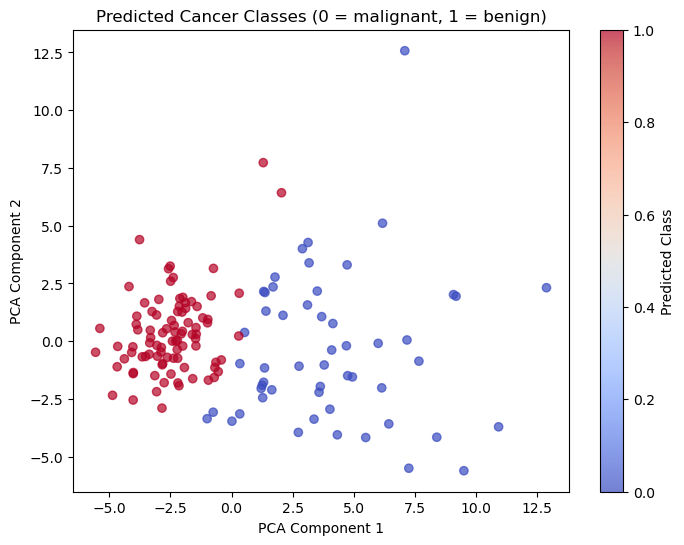

In [143]:
#visualise results from our prediction model
import matplotlib.pyplot as plt

# Get predictions from the test set
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 6))

# Plot predicted classes
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='coolwarm', alpha=0.7)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Predicted Cancer Classes (0 = malignant, 1 = benign)")
plt.colorbar(label="Predicted Class")
plt.show()